# 05 · Causal Inference Without an A/B Test

Quasi-experimental methods for cases where randomisation is not possible:
* Difference-in-Differences, estimated from group means and with OLS
* Matching and propensity-score matching (`causalinference`, `causalml`)
* Inverse propensity weighting (`dowhy`)
* Instrumental variables (`doubleml`)
* Synthetic control / Bayesian structural time series (`pycausalimpact`)

## 1. Diff-in-Diff

Suppose we have two stores (store_A and store_B) and we introduced a change (a new pricing policy) in store_B.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [ ]:
years = np.arange(2010, 2021)


store_A_sales_1 =  np.random.randint(70, 75, size=5)
store_A_sales_2 = np.random.randint(95, 100, size=6)
store_B_sales =  np.random.randint(60, 65, size=11)

data = {
    'store': ['B']*11 + ['A']*11,
    'year': np.concatenate([years]*2),
    'sales': np.concatenate([store_A_sales_1, store_A_sales_2, store_B_sales])
}
df = pd.DataFrame(data)
df['year'] = df['year'].astype(int)


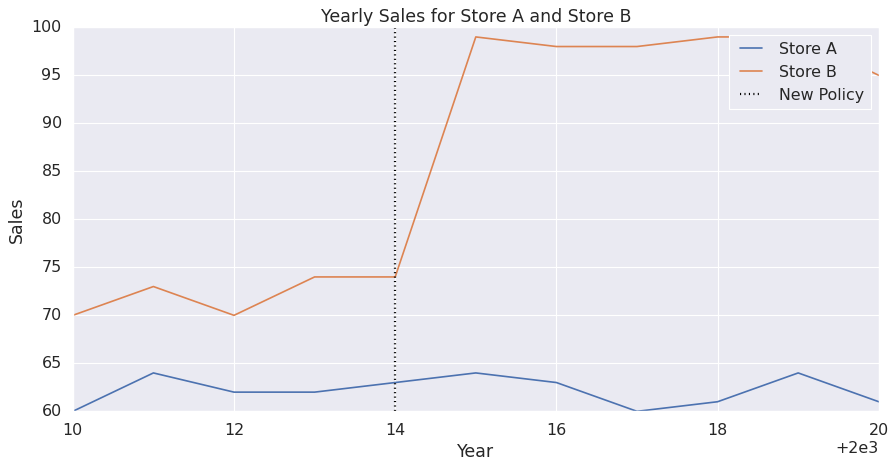

In [ ]:
plt.figure(figsize=(13, 6))

store_A_data = df[df['store'] == 'A']
store_B_data = df[df['store'] == 'B']

plt.plot(store_A_data['year'], store_A_data['sales'], label='Store A')
plt.plot(store_B_data['year'], store_B_data['sales'], label='Store B')
plt.axvline(x=2014, ymin=0, ymax=110, linestyle=":", lw=2, color='black', label="New Policy")

plt.xlabel('Year')
plt.ylabel('Sales')
plt.title('Yearly Sales for Store A and Store B')
plt.legend()

plt.grid(True)
plt.show()

In [ ]:
df['treatment'] = (df['store'] == 'B').astype(int)
df['post'] = (df['year'] >= 2015).astype(int)
df['treatment_post'] = df['treatment'] * df['post']
df.sample(5)

,store,year,sales,treatment,post,treatment_post
19,A,2018,61,0,1,0
5,B,2015,99,1,1,1
7,B,2017,98,1,1,1
18,A,2017,60,0,1,0
10,B,2020,95,1,1,1


In [ ]:
diff1 = np.mean(df[(df['treatment'] == 1) & (df['post'] == 0)]['sales']) - np.mean(df[(df['treatment'] == 0) & (df['post'] == 0)]['sales'])
diff2 = np.mean(df[(df['treatment'] == 1) & (df['post'] == 1)]['sales']) - np.mean(df[(df['treatment'] == 0) & (df['post'] == 1)]['sales'])

print(f"DiD difference: {diff2 - diff1}")

Simple difference of means: 25.833333333333336


In [ ]:
# Difference-in-Differences analysis using Ordinary Least Squares (OLS)
X = df[['treatment', 'post', 'treatment_post']]
X = sm.add_constant(X)
y = df['sales']

# Fit OLS model
model = sm.OLS(y, X).fit()

# Print regression results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     755.1
Date:                Thu, 03 Oct 2024   Prob (F-statistic):           4.13e-19
Time:                        09:04:37   Log-Likelihood:                -37.505
No. Observations:                  22   AIC:                             83.01
Df Residuals:                      18   BIC:                             87.37
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             61.0000      0.658     92.

The regression coefficient `treatment_post` is the difference-in-differences effect. If this coefficient is statistically significant, the new pricing policy performs better.


## 2. Matching (PSM)

In [ ]:
!pip install causalinference

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 2.0 MB/s eta 0:00:00


In [ ]:
!pip install causalml

In [ ]:
# Import libraries
import pandas as pd
import statsmodels.api as sm

In [ ]:
# Dataset: wages as a function of sex (and other covariates)
df = sm.datasets.get_rdataset("Wages", package="plm")

# Access the data part of the dataset
df = df.data
df

,exp,wks,bluecol,ind,south,smsa,married,sex,union,ed,black,lwage
0,3,32,no,0,yes,no,yes,male,no,9,no,5.56068
1,4,43,no,0,yes,no,yes,male,no,9,no,5.72031
2,5,40,no,0,yes,no,yes,male,no,9,no,5.99645
3,6,39,no,0,yes,no,yes,male,no,9,no,5.99645
4,7,42,no,1,yes,no,yes,male,no,9,no,6.06146
...,...,...,...,...,...,...,...,...,...,...,...,...
4160,3,50,no,0,no,yes,no,female,no,12,no,5.95324
4161,4,49,no,0,no,yes,no,female,no,12,no,6.06379
4162,5,50,no,0,no,yes,no,female,no,12,no,6.21461
4163,6,50,no,0,no,yes,no,female,no,12,no,6.29157


In [ ]:
df = pd.get_dummies(data=df, drop_first=True)
Y = df.loc[:, "lwage"].values
X = df.loc[:, "sex_male"].values.astype(int)
confounders = df.drop(columns=["sex_male", "lwage"]).values.astype(float)

In [ ]:
from causalinference import CausalModel

model = CausalModel(Y, X, confounders)
model.est_via_matching(bias_adj=True)
print(model.estimates)


Treatment Effect Estimates: Matching

                     Est.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
           ATE      0.276      0.065      4.215      0.000      0.148      0.404
           ATC      0.421      0.062      6.789      0.000      0.299      0.542
           ATT      0.258      0.072      3.566      0.000      0.116      0.399



### Option 2

In [ ]:
np.mean(df[df.sex_male==1]['lwage']) - np.mean(df[df.sex_male==0]['lwage'])

0.474466059596498

In [ ]:
from causalml.propensity import LogisticRegressionPropensityModel
from causalml.match import NearestNeighborMatch, create_table_one

# Each model has its own parameters, which can be found in the documentation:
#   - XGBoost for GradientBoostedPropensityModel
#   - sklearn for LogisticRegressionPropensityModel/ElasticNetPropensityModel
pm = LogisticRegressionPropensityModel()
ps = pm.fit_predict( df[df.columns.drop('sex_male')], df['sex_male'] ) # returns a numpy array of propensity scores
df['ps'] = pd.Series(ps)
df

,exp,wks,ind,ed,lwage,bluecol_yes,south_yes,smsa_yes,married_yes,sex_male,union_yes,black_yes,ps
0,3,32,0,9,5.56068,False,True,False,True,True,False,False,0.995978
1,4,43,0,9,5.72031,False,True,False,True,True,False,False,0.994976
2,5,40,0,9,5.99645,False,True,False,True,True,False,False,0.995681
3,6,39,0,9,5.99645,False,True,False,True,True,False,False,0.995698
4,7,42,1,9,6.06146,False,True,False,True,True,False,False,0.997264
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4160,3,50,0,12,5.95324,False,False,True,False,False,False,False,0.403787
4161,4,49,0,12,6.06379,False,False,True,False,False,False,False,0.422920
4162,5,50,0,12,6.21461,False,False,True,False,False,False,False,0.429668
4163,6,50,0,12,6.29157,False,False,True,False,False,False,False,0.433417


In [ ]:
psm = NearestNeighborMatch(replace=False,      # matching with or without replacement
                           caliper=0.1,        # distance threshold below which units are matched
                           random_state=42     # equivalent of random_seed
)


# instead of match, match_by_group can be used for stratified matching;
# pass groupby_col to specify the column to stratify by
matched = psm.match(data=df,
                    treatment_col='sex_male',
                    score_cols=['ps']             # for plain covariate matching, pass covariate columns instead of the PS
)

#
create_table_one(data=matched,
                 treatment_col='sex_male',
                 features=df.columns.drop(['ps','sex_male']).tolist()
)

,Control,Treatment,SMD
Variable,,,
n,274,274,
black_yes,0.13 (0.33),0.14 (0.35),0.0426
bluecol_yes,0.40 (0.49),0.44 (0.50),0.0813
ed,12.82 (2.58),13.48 (2.44),0.2647
exp,14.97 (8.45),15.34 (10.02),0.0398
ind,0.19 (0.39),0.23 (0.42),0.1079
lwage,6.28 (0.42),6.62 (0.48),0.7597
married_yes,0.04 (0.21),0.04 (0.21),0.0
smsa_yes,0.71 (0.46),0.75 (0.43),0.0986


In [ ]:
matched

,exp,wks,ind,ed,lwage,bluecol_yes,south_yes,smsa_yes,married_yes,sex_male,union_yes,black_yes,ps
1139,15,50,1,12,6.52209,True,True,True,True,True,True,False,0.995311
761,30,47,1,12,7.29980,True,False,True,True,True,False,False,0.995124
371,13,47,1,11,6.51175,True,False,False,True,True,True,False,0.997376
3343,7,49,1,16,6.63595,False,False,True,True,True,True,False,0.995236
1813,10,49,0,12,6.55108,True,False,True,True,True,False,False,0.992404
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2282,10,39,0,12,5.93225,True,True,True,False,False,False,True,0.265171
3119,7,40,0,16,6.44731,False,True,False,False,False,False,False,0.499887
3118,6,47,0,16,5.89440,False,True,True,False,False,False,False,0.244823
21,31,52,0,10,6.15698,True,False,True,False,False,False,True,0.164041


In [ ]:
# matched is a subset of the dataframe in which every treated unit
# is matched to at least one control unit, so the effect can be computed as in a regular A/B test
ATT = np.mean(matched[matched.sex_male==1]['lwage']) - np.mean(matched[matched.sex_male==0]['lwage'])
ATT

0.3428928102189781

## 3. Weighting

In [ ]:
!pip install dowhy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.4/383.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.5/174.5 kB 4.7 MB/s eta 0:00:00


In [ ]:
list(df.drop(['sex_male', 'lwage'], axis=1).columns)

['exp',
 'wks',
 'ind',
 'ed',
 'bluecol_yes',
 'south_yes',
 'smsa_yes',
 'married_yes',
 'union_yes',
 'black_yes']

In [ ]:
import pandas as pd
import dowhy
from dowhy import CausalModel

df = df.astype(float)

model=CausalModel(
        data = df,
        treatment="sex_male",
        outcome="lwage",
        common_causes=df.drop(['sex_male', 'lwage'], axis=1).columns.tolist() # should be a list
)

identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

#Causal Effect Estimation
estimate = model.estimate_effect(identified_estimand,
                                 method_name = "backdoor.propensity_score_weighting",
                                 # for vanila IPS, also can use "ips_normalized_weight" (Hajek Self-normalized IPS)
                                 # or "ips_stabilized_weight" (Stabilized IPS)
                                 method_params={"weighting_scheme":"ips_weight"},
                                 target_units = "ate" # att, atc, lambda function that filters rows
)
print(estimate)
print("Causal Estimate is " + str(estimate.value))


*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                                                                                             
──────────(E[lwage|married_yes,south_yes,ind,ed,wks,smsa_yes,union_yes,bluecol_yes,exp,black_yes])
d[sexₘₐₗₑ]                                                                                        
Estimand assumption 1, Unconfoundedness: If U→{sex_male} and U→lwage then P(lwage|sex_male,married_yes,south_yes,ind,ed,wks,smsa_yes,union_yes,bluecol_yes,exp,black_yes,U) = P(lwage|sex_male,married_yes,south_yes,ind,ed,wks,smsa_yes,union_yes,bluecol_yes,exp,black_yes)

## Realized estimand
b: lwage~sex_male+married_yes+south_yes+ind+ed+wks+smsa_yes+union_yes+bluecol_yes+exp+black_yes
Target units: ate

## Estimate
Mean value: 0.4179064541737576

Causal Estimate is 0.4179064541737576


## 4. IV

More details: https://docs.doubleml.org/stable/examples/py_double_ml_basic_iv.html

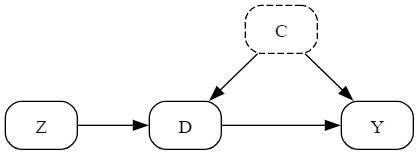

In [ ]:
!pip install doubleml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.1/318.1 kB 4.8 MB/s eta 0:00:00


In [ ]:
from numpy.random import seed, normal, binomial, uniform
from pandas import DataFrame
from sklearn.linear_model import LinearRegression, LogisticRegression
import doubleml as dml

seed(1234)

In [ ]:
n = 1000
instrument_impact = 0.7
decision_impact = - 2

confounder = binomial(1, 0.3, n)
instrument = binomial(1, 0.5, n)
decision = (uniform(0, 1, n) <= instrument_impact*instrument + 0.4*confounder).astype(int)
outcome = 30 + decision_impact*decision + 10 * confounder + normal(0, 2, n)

df = DataFrame({
    'instrument': instrument,
    'decision': decision,
    'outcome': outcome
})
df

,instrument,decision,outcome
0,0,0,32.973065
1,1,1,36.760270
2,0,0,39.280473
3,1,1,28.473959
4,0,0,31.418265
...,...,...,...
995,0,0,28.271490
996,1,0,28.361484
997,1,1,39.660128
998,0,0,40.001349


In [ ]:
outcome_1 = df[df.decision==1].outcome.mean()
outcome_0 = df[df.decision==0].outcome.mean()
print(outcome_1 - outcome_0)

0.6204305130985937


ml_g models the functional relationship betwen the outcome and the pair instrument and observed confounders obs_confounders. In this case we choose a LinearRegression because the outcome is continuous.

ml_m models the functional relationship betwen the obs_confounders and the instrument. In this case we choose a LogisticRegression because the outcome is dichotomic.

ml_r models the functional relationship betwen the decision and the pair instrument and observed confounders obs_confounders. In this case we choose a LogisticRegression because the outcome is dichotomic.

In [ ]:
df['obs_confounders'] = 1

ml_g = LinearRegression()
ml_m = LogisticRegression(penalty=None)
ml_r = LogisticRegression(penalty=None)

obj_dml_data = dml.DoubleMLData(
    df, y_col='outcome', d_cols='decision',
    z_cols='instrument', x_cols='obs_confounders'
)
dml_iivm_obj = dml.DoubleMLIIVM(obj_dml_data, ml_g, ml_m, ml_r)
print(dml_iivm_obj.fit().summary)

              coef   std err        t         P>|t|     2.5 %    97.5 %
decision -2.490214  0.468422 -5.31618  1.059680e-07 -3.408303 -1.572124


## 5. Synthetic Control

In [ ]:
!pip install pycausalimpact

In [ ]:
import yfinance as yf
from causalimpact import CausalImpact
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Dates
training_start = "2020-09-01"
training_end = "2020-10-19"
treatment_start = "2020-10-20"
treatment_end = "2020-10-23"
end_stock = "2020-10-24"


In [ ]:
#Bitcoin
y = ["BTC-USD"]
y = yf.download(tickers=y,
                start=training_start,
                end=end_stock,
                interval="1d")
y = y["Adj Close"].rename("y")
y[:1]


[*********************100%***********************]  1 of 1 completed


,y
Date,
2020-09-01,11970.478516


In [ ]:
#Load More Data
Stock = ["ZAL.DE", "SQ", "CRSP", "TRMB", "JD", "KTOS", "GOOG"]
X = yf.download(tickers=Stock,
                start = training_start,
                end = end_stock,
                interval ="1d")
X.head()

[*********************100%***********************]  7 of 7 completed


Price                      Adj Close                                   \
Ticker                          CRSP       GOOG         JD       KTOS   
Date                                                                    
2020-09-01 00:00:00+00:00  93.419998  82.832077  77.058540  19.700001   
2020-09-02 00:00:00+00:00  93.930000  86.202309  77.731133  19.910000   
2020-09-03 00:00:00+00:00  85.690002  81.890900  73.835701  19.520000   
2020-09-04 00:00:00+00:00  82.019997  79.357117  74.732498  19.260000   
2020-09-07 00:00:00+00:00        NaN        NaN        NaN        NaN   

Price                                                            Close  \
Ticker                             SQ       TRMB     ZAL.DE       CRSP   
Date                                                                     
2020-09-01 00:00:00+00:00  166.660004  53.410000  77.000000  93.419998   
2020-09-02 00:00:00+00:00  162.880005  54.310001  77.000000  93.930000   
2020-09-03 00:00:00+00:00  152.860001  50.900002  75.080002  85.690002   
2020-09-04 00:00:00+00:00  146.389999  49.959999  71.739998  82.019997   
2020-09-07 00:00:00+00:00         NaN        NaN  74.000000        NaN   

Price                                            ...        Open             \
Ticker                          GOOG         JD  ...          SQ       TRMB   
Date                                             ...                          
2020-09-01 00:00:00+00:00  83.035500  82.489998  ...  164.809998  52.669998   
2020-09-02 00:00:00+00:00  86.414001  83.209999  ...  170.600006  53.779999   
2020-09-03 00:00:00+00:00  82.092003  79.040001  ...  157.000000  54.130001   
2020-09-04 00:00:00+00:00  79.552002  80.000000  ...  149.630005  51.040001   
2020-09-07 00:00:00+00:00        NaN        NaN  ...         NaN        NaN   

Price                                    Volume                          \
Ticker                        ZAL.DE       CRSP        GOOG          JD   
Date                                                                      
2020-09-01 00:00:00+00:00  74.959999   779500.0  36506000.0  11431400.0   
2020-09-02 00:00:00+00:00  77.500000   532000.0  50224000.0  13860900.0   
2020-09-03 00:00:00+00:00  77.260002  1278900.0  62156000.0  19254000.0   
2020-09-04 00:00:00+00:00  74.800003  1570300.0  52172000.0  21500900.0   
2020-09-07 00:00:00+00:00  72.239998        NaN         NaN         NaN   

Price                                                                
Ticker                          KTOS          SQ       TRMB  ZAL.DE  
Date                                                                 
2020-09-01 00:00:00+00:00   587600.0  12306400.0   542300.0  790198  
2020-09-02 00:00:00+00:00   612800.0  11214800.0   728800.0  496554  
2020-09-03 00:00:00+00:00   847100.0  16421200.0  1220300.0  736259  
2020-09-04 00:00:00+00:00  1060000.0  17995200.0   914700.0  662250  
2020-09-07 00:00:00+00:00        NaN         NaN        NaN  362062  

[5 rows x 42 columns]

In [ ]:
X = X.iloc[:,:len(Stock)]
X.head(1)

Price                      Adj Close                                  \
Ticker                          CRSP       GOOG        JD       KTOS   
Date                                                                   
2020-09-01 00:00:00+00:00  93.419998  82.832077  77.05854  19.700001   

Price                                                
Ticker                             SQ   TRMB ZAL.DE  
Date                                                 
2020-09-01 00:00:00+00:00  166.660004  53.41   77.0

In [ ]:
#remove droplevel column
X.columns = X.columns.droplevel()

#Time Zones
X.index = X.index.tz_localize(None)

X = pd.concat([y, X], axis=1).dropna()
X.tail()

df_training = X.loc[X.index <= training_end]
differencing = X.pct_change().dropna()

df_final = X.drop(columns = ['ZAL.DE'])
df_final.tail()

pre_period = [training_start, training_end]
post_period = [treatment_start, treatment_end]

In [ ]:
df_final.sample(5)

,y,CRSP,GOOG,JD,KTOS,SQ,TRMB
Date,,,,,,,
2020-10-12,11555.363281,99.400002,78.265289,78.768044,21.280001,185.169998,52.310001
2020-10-09,11064.458008,98.260002,75.575401,74.536324,20.889999,187.279999,51.380001
2020-09-08,10131.516602,81.459999,76.431801,71.201378,19.230000,139.110001,49.139999
2020-10-06,10604.406250,87.720001,72.493965,71.640442,19.700001,175.339996,48.930000
2020-09-17,10948.990234,85.139999,74.593307,69.473190,21.530001,145.639999,49.790001


In [ ]:
impact = CausalImpact(df_final, pre_period, post_period)

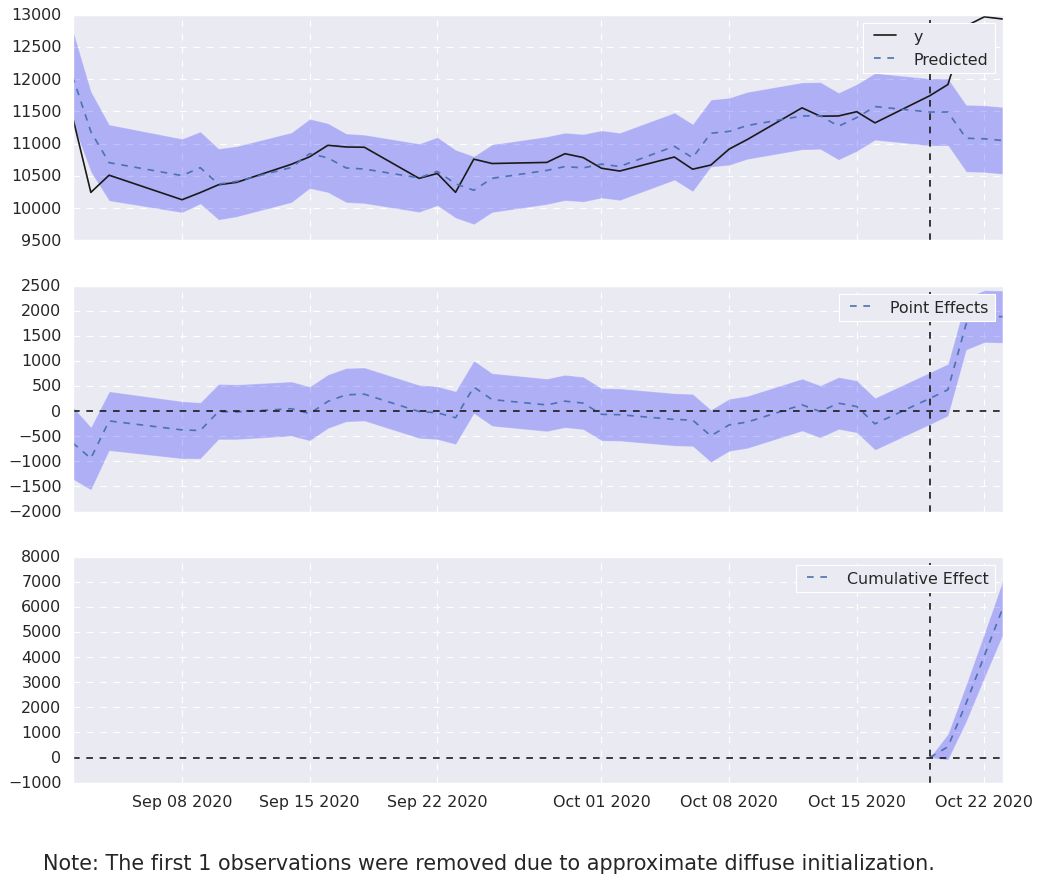

In [ ]:
impact.plot()

In [ ]:
print(impact.summary('report'))

Analysis report {CausalImpact}


During the post-intervention period, the response variable had
an average value of approx. 12659.36. By contrast, in the absence of an
intervention, we would have expected an average response of 11174.97.
The 95% interval of this counterfactual prediction is [10898.1, 11441.71].
Subtracting this prediction from the observed response yields
an estimate of the causal effect the intervention had on the
response variable. This effect is 1484.39 with a 95% interval of
[1217.65, 1761.26]. For a discussion of the significance of this effect,
see below.


Summing up the individual data points during the post-intervention
period (which can only sometimes be meaningfully interpreted), the
response variable had an overall value of 50637.46.
By contrast, had the intervention not taken place, we would have expected
a sum of 44699.89. The 95% interval of this prediction is [43592.4, 45766.85].


The above results are given in terms of absolute numbers. In relative
te